# Matplotlib — Financial Data Visualisation — Week 1
**Aayan Mulani │ Decimal Point Analytics Preparation**

Matplotlib is the core Python plotting library in Python.
In finance, charts are how you communicate insights to clients —
a well-labelled chart is worth more than a table of numbers.
We will build 4 charts today: price history, moving averages,
returns distribution, and a 5-stock cumulative returns comparison.

In [8]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

# Download 2 years of Nifty 50 closing prices
nifty = yf.download('^NSEI', start='2023-01-01', end='2025-01-01')['Close']

print(type(nifty))
print(nifty.shape)
print(nifty.head())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
(491, 1)
Ticker             ^NSEI
Date                    
2023-01-02  18197.449219
2023-01-03  18232.550781
2023-01-04  18042.949219
2023-01-05  17992.150391
2023-01-06  17859.449219


## 1. Nifty 50 Price History Chart
A line chart showing the closing price of the Nifty 50 index
from Jan 2023 to Jan 2025. This is the most basic and most
important chart in financial analysis.

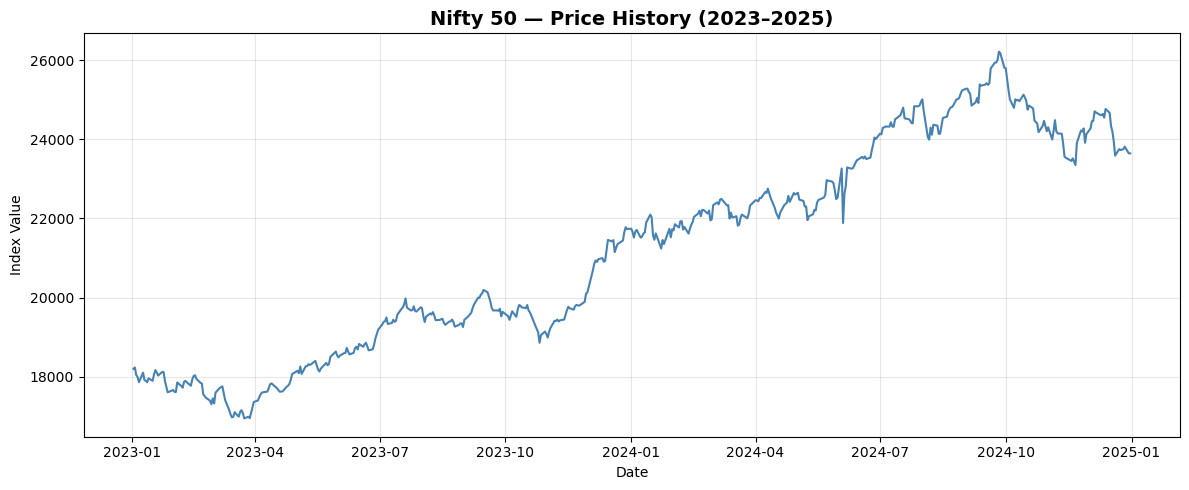

In [27]:
# Squeeze DataFrame into a Series for clean plotting
nifty = nifty.squeeze()

# Basic line chart
plt.figure(figsize=(12, 5))
plt.plot(nifty.index, nifty.values, color='steelblue', linewidth=1.5)
plt.title('Nifty 50 — Price History (2023–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Moving Averages — Trend Identification
A moving average smooths out daily noise and reveals the underlying trend.
The 50-day MA captures short-term trend; the 200-day MA captures long-term trend.
When MA50 crosses above MA200 → 'Golden Cross' (bullish signal).
When MA50 crosses below MA200 → 'Death Cross' (bearish signal).

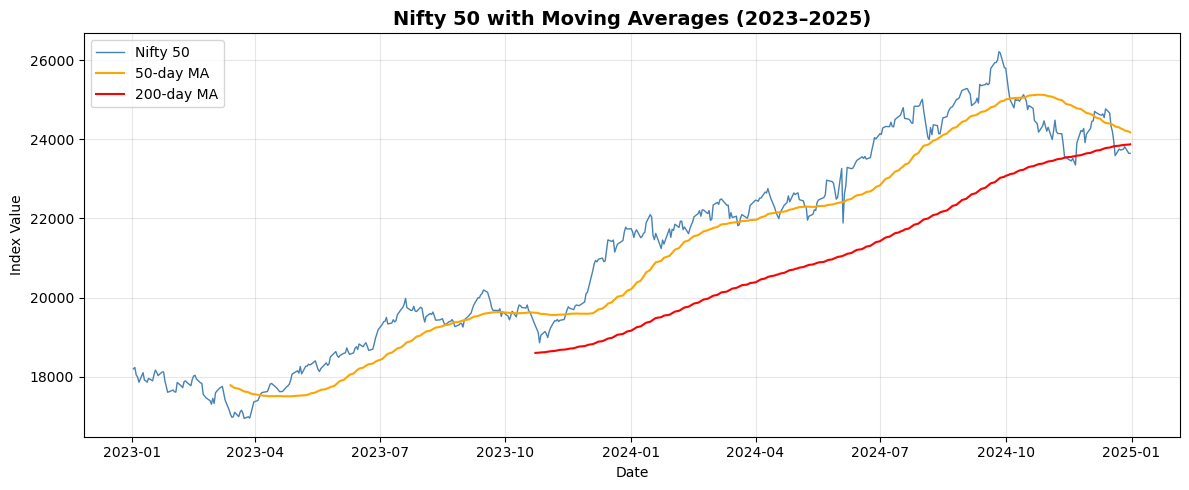

In [35]:
# Build a DataFrame with the MAs
nifty_df = nifty.to_frame(name='Close')
nifty_df['MA50']  = nifty_df['Close'].rolling(50).mean()
nifty_df['MA200'] = nifty_df['Close'].rolling(200).mean()

plt.figure(figsize=(12, 5))
plt.plot(nifty_df['Close'],  label='Nifty 50',   color='steelblue', linewidth=1)
plt.plot(nifty_df['MA50'],   label='50-day MA',  color='orange',    linewidth=1.5)
plt.plot(nifty_df['MA200'],  label='200-day MA', color='red',       linewidth=1.5)
plt.title('Nifty 50 with Moving Averages (2023–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Returns Distribution
A histogram showing how daily returns are distributed.
We overlay a vertical line at the mean and std dev.
Fat tails (more extreme values than a normal curve) are
a key feature of real stock return data.

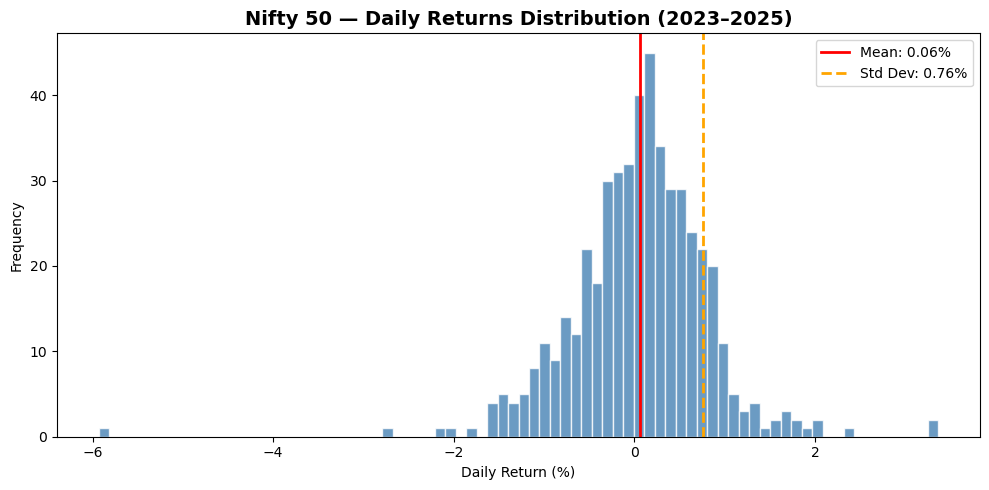

In [36]:
returns = nifty.pct_change().dropna() * 100  # convert to percentage

plt.figure(figsize=(10, 5))
plt.hist(returns, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(returns.mean(), color='red',    linewidth=2, 
            label=f'Mean: {returns.mean():.2f}%')
plt.axvline(returns.std(), color='orange',  linewidth=2, linestyle='--', 
            label=f'Std Dev: {returns.std():.2f}%')
plt.title('Nifty 50 — Daily Returns Distribution (2023–2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Cumulative Returns — 5 Indian Stocks Comparison (2022–2025)
Cumulative return shows how Rs 1 invested in each stock at the
start would have grown over time. Formula: (1+r1)*(1+r2)*...-1
This is the most intuitive way to compare performance across stocks.

[*********************100%***********************]  5 of 5 completed


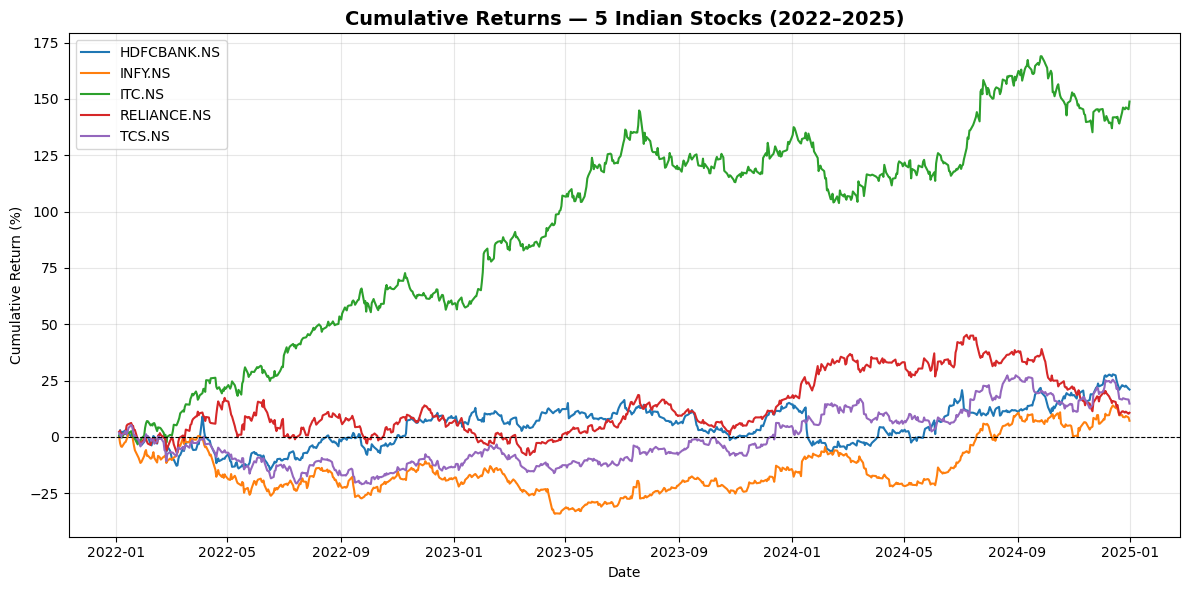

In [37]:
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ITC.NS']
stocks = yf.download(tickers, start='2022-01-01', end='2025-01-01')['Close']
cum_returns = (1 + stocks.pct_change().dropna()).cumprod() - 1

plt.figure(figsize=(12, 6))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col] * 100, label=col)

plt.title('Cumulative Returns — 5 Indian Stocks (2022–2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary — Day 6 Matplotlib

Four charts built today:
1. Price History — shows Nifty's +32% journey from 18,000 to 24,000
2. Moving Averages — MA50 and MA200 confirmed a sustained bullish trend
3. Returns Distribution — negative skew and fat left tail visible in Nifty returns
4. Cumulative Returns — ITC dominated at +150%; INFY was underwater for most of 3 years

Key Matplotlib functions used:
- plt.plot() — line chart
- plt.hist() — histogram
- plt.axvline() / plt.axhline() — reference lines
- plt.legend(), plt.grid(), plt.tight_layout() — chart polish